### Library
Kode digunakan untuk mengimport library yang membantu memprosesan perhitungan dalam citra digital

In [78]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Menampilkan Citra RGB dan Grayscale

Kode digunakan untuk membaca gambar `Telapak.jpeg` lalu menampilkan citra asli RGB dan citra grayscale. Konversi grayscale dilakukan agar proses pengolahan citra menjadi lebih mudah karena hanya menggunakan intensitas abu-abu.

(4032, 3024, 3)
(4032, 3024)


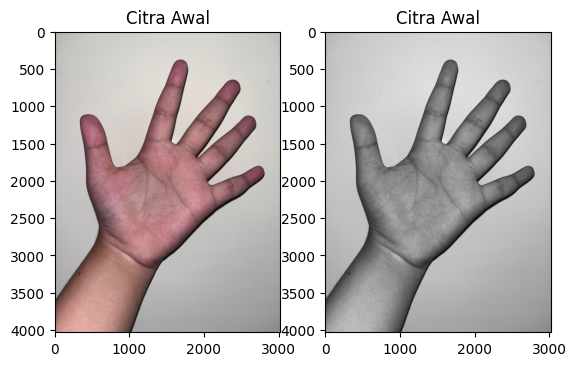

In [79]:
Tangan = cv2.imread('Telapak.jpeg')
Tangangray = cv2.cvtColor(Tangan, cv2.COLOR_BGR2GRAY)
gambarRGB = cv2.cvtColor(Tangan, cv2.COLOR_BGR2RGB)
plt.subplot(1, 2, 1)
print(gambarRGB.shape)
plt.title("Citra Awal")
plt.imshow(gambarRGB, cmap='gray')

Tangann = cv2.imread('Telapak.jpeg', cv2.IMREAD_GRAYSCALE)
plt.subplot(1, 2, 2)
print(Tangann.shape)
plt.title("Citra Awal")
plt.imshow(Tangann, cmap = "gray")

## Fungsi Konvolusi

Kode digunakan untuk membuat proses konvolusi secara manual pada citra grayscale menggunakan kernel tertentu. Proses ini dilakukan dengan menambahkan padding, mengambil area kernel pada setiap piksel, lalu menghitung hasil perkalian antara kernel dan area citra.

Fungsi konvolusi digunakan sebagai dasar untuk proses smoothing, sharpening, dan deteksi tepi pada citra digital.

In [80]:
def convolution(img, kernel):

    # ukuran kernel / kernel size
    size = kernel.shape[0]

    # ukuran padding / padding size
    pad_size = size // 2

    # tambah padding nol / add zero padding
    padded = np.pad(img, pad_size, mode='constant')

    # kanvas hasil / output canvas
    canvas = np.zeros_like(img).astype(np.float32)

    # dimensi gambar / image dimensions
    height, width = img.shape

    # loop baris / loop rows
    for i in range(height):

        # loop kolom / loop columns
        for j in range(width):

            # area kernel / kernel region
            region = padded[i:i+size, j:j+size]

            # hitung konvolusi / compute convolution
            canvas[i, j] = np.sum(region * kernel)

    # kembalikan gambar / return image
    return canvas

## Kernel Smoothing dan Sharpening

Kode digunakan untuk membuat kernel smoothing dan sharpening. Kernel smoothing berfungsi untuk menghaluskan citra dan mengurangi noise, sedangkan kernel sharpening digunakan untuk mempertegas detail dan tepi objek pada gambar.

In [81]:
# kernel penghalus gambar / image smoothing kernel
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

# kernel penajam gambar / image sharpening kernel
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

## Fungsi Edge Detection

Kode digunakan untuk melakukan deteksi tepi pada citra menggunakan konvolusi sumbu X dan Y. Hasil gradien kedua arah digabung dan dinormalisasi sehingga kontur atau batas objek pada gambar terlihat lebih jelas.

In [82]:
def edge(img, kernelx, kernely):
    # konvolusi sumbu x / x-axis convolution
    gx = convolution(img, kernelx)
    # konvolusi sumbu y / y-axis convolution
    gy = convolution(img, kernely)
    # kanvas kosong / empty canvas
    canvas = np. zeros_like(img, dtype=np. float32)
    # gabung gradien absolut / combine absolute gradients
    canvas = np.abs(gx) + np.abs(gy)
    # normalisasi ke 0-255 / normalize to 0-255
    canvas = canvas * 255.0 / np.max (canvas)
    # batas nilai dan konversi / clip values and convert
    return np.clip(canvas, 0, 255).astype(np.uint8)

# cara panggil / how to call
# hasil_tepi = edge(fotoTania, prewittX, prewittY)

## Kernel Sobel

Kode digunakan untuk membuat kernel Sobel pada sumbu X dan Y. Operator Sobel digunakan untuk mendeteksi tepi dengan menonjolkan perubahan intensitas piksel secara horizontal dan vertikal sehingga kontur objek terlihat lebih jelas.

In [83]:
# kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)
# kernel sobel sumbu y / y-axis sobel kernel
sobelY = np. array([
    [ 1, 2, 1],
    [ 0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

## Kernel Prewitt

Kode digunakan untuk membuat kernel Prewitt pada sumbu X dan Y. Operator Prewitt digunakan untuk mendeteksi tepi objek dengan menghitung perubahan intensitas citra pada arah horizontal dan vertikal.

In [84]:
# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)
# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

## Kernel Roberts

Kode digunakan untuk membuat kernel Roberts pada sumbu X dan Y. Operator Roberts digunakan untuk mendeteksi tepi berdasarkan perubahan intensitas diagonal sehingga tepi objek tipis dapat terlihat lebih jelas.

In [85]:
# kernel roberts sumbu x / x-axis roberts kernel
robertsX = np. array([
    [1,  0],
    [0, -1],
], dtype=np. float32)
# kernel sobel sumbu y / y-axis sobel kernel
robertsY = np. array ([
    [0,  1],
    [-1, 0],
], dtype=np. float32)

## Threshold

Kode digunakan untuk melakukan proses thresholding pada citra. Piksel yang memiliki nilai lebih besar dari batas threshold akan diubah menjadi putih (255), sedangkan piksel di bawah atau sama dengan batas akan diubah menjadi hitam (0). Proses ini digunakan untuk memisahkan objek dan background.

In [86]:
def threshold(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):

            if(img[i,j] > batas):
                canvas[i,j] = 255

            elif(img[i,j] <= batas):
                canvas[i,j] = 0

    return canvas

## Resized

Kode digunakan untuk mengubah ukuran citra menjadi lebar dan tinggi baru. Proses resize dilakukan dengan mengambil nilai piksel dari posisi terdekat pada citra asli sehingga ukuran gambar dapat diperbesar atau diperkecil.

In [87]:
def resized(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

## Normalisasi

Kode digunakan untuk melakukan normalisasi nilai intensitas citra ke rentang 0–1. Proses ini membantu menyesuaikan distribusi nilai piksel agar lebih stabil dan mudah digunakan pada proses pengolahan citra berikutnya.

In [88]:
def normalisasi(citra):
    c_min = np.min(citra)
    c_max = np.max(citra)
    normalized = (citra - c_min) / (c_max - c_min) if (c_max - c_min) != 0 else np.zeros_like(citra)
    return normalized

## Resize, Deteksi Tepi, dan Threshold

Kode digunakan untuk melakukan beberapa tahapan pengolahan citra pada gambar telapak tangan. Pertama, citra diubah ukurannya menjadi 256×256 piksel agar proses pengolahan lebih ringan dan seragam. Setelah itu dilakukan deteksi tepi menggunakan operator Sobel untuk menampilkan garis tepi pada objek telapak tangan. Hasil deteksi tepi kemudian diproses menggunakan threshold dengan nilai 20 sehingga tepi objek terlihat lebih jelas dalam bentuk citra biner hitam putih.

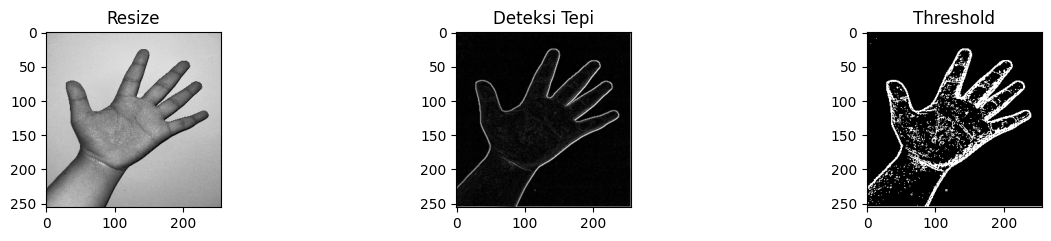

In [89]:
hasil_resize = resized(Tangann, 256, 256)
hasil_tepi = edge(hasil_resize, sobelX, sobelY)
Threshold20 = threshold(hasil_tepi, 20)

plt.figure(figsize=(15,5))

plt.subplot(2,3,1)
plt.imshow(hasil_resize, cmap='gray')
plt.title('Resize')

plt.subplot(2,3,2)
plt.imshow(hasil_tepi, cmap='gray')
plt.title('Deteksi Tepi')

plt.subplot(2,3,3)
plt.imshow(Threshold20, cmap='gray')
plt.title('Threshold')

plt.show()

## Analisis Hasil Resize, Deteksi Tepi, dan Threshold

Pada gambar **Resize**, citra telapak tangan berhasil diubah ukurannya menjadi 256×256 piksel tanpa menghilangkan bentuk utama objek. Proses resize membuat ukuran citra lebih seragam sehingga lebih mudah diproses pada tahap berikutnya.

Pada gambar **Deteksi Tepi**, operator Sobel berhasil menampilkan garis-garis tepi pada telapak tangan dan jari-jari. Bagian tepi terlihat lebih terang dibandingkan area lain karena adanya perubahan intensitas piksel yang cukup besar.

Pada gambar **Threshold**, hasil deteksi tepi diubah menjadi citra biner hitam putih. Garis tepi telapak tangan terlihat semakin jelas, namun masih terdapat beberapa noise pada bagian dalam tangan akibat nilai threshold yang cukup rendah. Secara keseluruhan, proses threshold berhasil memisahkan area tepi objek dari background.

# Kernel Morfologi

Kode digunakan untuk membuat beberapa bentuk kernel (structuring element) yang digunakan pada operasi morfologi citra.

- **Kernel Diamond** digunakan untuk proses morfologi dengan bentuk menyerupai berlian sehingga efek operasi lebih fokus pada area diagonal dan tengah objek.
- **Kernel Cross** digunakan untuk memproses area vertikal dan horizontal objek karena bentuknya menyerupai tanda tambah (+).
- **Kernel X** digunakan untuk menonjolkan area diagonal objek karena bentuk kernel menyerupai huruf X.

Perbedaan bentuk kernel mempengaruhi hasil operasi morfologi seperti dilasi, erosi, opening, dan closing pada citra.

In [90]:
kernel_diamond = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0]
])

kernel_cross = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])

kernel_x = np.array([
    [1, 0, 0, 0, 1],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1]
], dtype=np.uint8)

## Dilasi

Kode digunakan untuk melakukan operasi morfologi dilasi pada citra biner. Proses dilasi memperbesar area objek putih berdasarkan bentuk kernel yang digunakan sehingga garis atau objek menjadi lebih tebal dan bagian kecil yang terputus dapat tersambung kembali.

In [91]:
def dilasi(image, kernel):
  height, width = image.shape
  k_height, k_width = kernel.shape
  center = k_height//2
  hasil = np.zeros((height, width))
  for i in range(center, height-center):
    for j in range(center, width-center):
      if image[i,j] == 255:
        for k in range(k_height):
          for l in range(k_width):
            if kernel[k,l] == 1:
              hasil[i+k-center,j+l-center] =255
  return hasil

## Erosi

Kode digunakan untuk melakukan operasi erosi pada citra biner. Proses ini mengurangi atau menipiskan area objek putih berdasarkan bentuk kernel sehingga noise kecil dapat dihilangkan dan bentuk objek menjadi lebih rapi.

In [92]:
def erosi(citra, mask):
    pad_t, pad_l = mask.shape[0] // 2, mask.shape[1] // 2
    citra_pad = np.pad(citra, ((pad_t, pad_t), (pad_l, pad_l)), mode='constant', constant_values=255)
    hasil = np.zeros_like(citra, dtype=np.uint8)

    for r in range(pad_t, citra_pad.shape[0] - pad_t):
        for c in range(pad_l, citra_pad.shape[1] - pad_l):
            blok = citra_pad[r - pad_t:r + pad_t + 1, c - pad_l:c + pad_l + 1]
            if np.all(blok[mask == 1] == 255):
                hasil[r - pad_t, c - pad_l] = 255

    return hasil

## Opening dan Closing

Kode digunakan untuk melakukan operasi morfologi opening dan closing.  
Opening dilakukan dengan erosi lalu dilasi untuk menghilangkan noise kecil pada objek. Sedangkan closing dilakukan dengan dilasi lalu erosi untuk menutup celah atau lubang kecil pada objek sehingga bentuk objek menjadi lebih utuh.

In [93]:
def opening(img, kernel):
    hasil_erosi = erosi(img, kernel)
    hasil_opening = dilasi(hasil_erosi, kernel)
    return hasil_opening

def closing(img, kernel):
    hasil_dilasi = dilasi(img, kernel)
    hasil_closing = erosi(hasil_dilasi, kernel)
    return hasil_closing

## Thinning

Kode digunakan untuk melakukan proses thinning atau penipisan objek pada citra biner. Proses ini mengurangi ketebalan objek putih secara bertahap hingga menjadi garis tipis tanpa menghilangkan bentuk utama objek.

Metode thinning bekerja dengan memeriksa tetangga piksel pada dua tahap (step 1 dan step 2). Piksel tertentu akan dihapus jika memenuhi syarat jumlah tetangga dan pola transisi sehingga struktur objek tetap terjaga. Hasil akhirnya berupa skeleton atau kerangka objek yang lebih tipis dan jelas.

In [94]:
def thinning(img):
    binary = (img > 0).astype(np.uint8)

    height, width = binary.shape
    changed = True

    while changed:
        changed = False
        hapus = []

        # STEP 1
        for i in range(1, height - 1):
            for j in range(1, width - 1):

                P1 = binary[i, j]

                if P1 != 1:
                    continue

                P2 = binary[i - 1, j]
                P3 = binary[i - 1, j + 1]
                P4 = binary[i, j + 1]
                P5 = binary[i + 1, j + 1]
                P6 = binary[i + 1, j]
                P7 = binary[i + 1, j - 1]
                P8 = binary[i, j - 1]
                P9 = binary[i - 1, j - 1]

                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]

                jumlah = np.sum(tetangga)

                transisi = 0
                urutan = tetangga + [P2]

                for k in range(8):
                    if urutan[k] == 0 and urutan[k + 1] == 1:
                        transisi += 1

                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P6 == 0 and
                    P4 * P6 * P8 == 0
                ):
                    hapus.append((i, j))

        if hapus:
            changed = True

            for i, j in hapus:
                binary[i, j] = 0

        hapus = []

        # STEP 2
        for i in range(1, height - 1):
            for j in range(1, width - 1):

                P1 = binary[i, j]

                if P1 != 1:
                    continue

                P2 = binary[i - 1, j]
                P3 = binary[i - 1, j + 1]
                P4 = binary[i, j + 1]
                P5 = binary[i + 1, j + 1]
                P6 = binary[i + 1, j]
                P7 = binary[i + 1, j - 1]
                P8 = binary[i, j - 1]
                P9 = binary[i - 1, j - 1]

                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]

                jumlah = np.sum(tetangga)

                transisi = 0
                urutan = tetangga + [P2]

                for k in range(8):
                    if urutan[k] == 0 and urutan[k + 1] == 1:
                        transisi += 1

                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P8 == 0 and
                    P2 * P6 * P8 == 0
                ):
                    hapus.append((i, j))

        if hapus:
            changed = True

            for i, j in hapus:
                binary[i, j] = 0

    return binary * 255

## Thickening

Kode digunakan untuk melakukan proses thickening atau penebalan objek pada citra biner. Proses ini dilakukan dengan menerapkan operasi dilasi beberapa kali sesuai jumlah iterasi sehingga garis atau objek menjadi lebih tebal dan lebih jelas terlihat.

In [95]:
def thickening(img, kernel, iterasi=1):
  hasil = img.copy()
  for _ in range(iterasi):
    hasil = dilasi(hasil, kernel)
  return hasil

## Gradient Morfologi

Kode digunakan untuk menghasilkan citra gradient morfologi dengan menghitung selisih antara hasil dilasi dan erosi. Hasil gradient menampilkan bagian tepi objek karena area yang berubah setelah dilasi dan erosi akan terlihat lebih jelas.

In [96]:
def gradient(citra, mask):

    dilasiHasil = dilasi(citra, mask)
    erosiHasil = erosi(citra, mask)

    gradientHasil = dilasiHasil - erosiHasil

    return gradientHasil

## Kernel 3x3 dan 5x5

Kode digunakan untuk membuat kernel morfologi berukuran 3×3 dan 5×5 yang seluruh elemennya bernilai 1. Kernel ini digunakan pada operasi morfologi seperti dilasi, erosi, opening, dan closing. Kernel 3×3 memberikan efek perubahan yang lebih kecil dan detail, sedangkan kernel 5×5 memberikan efek yang lebih besar seperti penebalan objek atau penghapusan noise yang lebih kuat.

In [97]:
kernel3x3 = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

kernel5x5 = np.array([
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1]
], dtype=np.uint8)

## Operasi Morfologi Menggunakan Kernel 3x3

Kode digunakan untuk menerapkan beberapa operasi morfologi pada citra hasil threshold menggunakan kernel 3×3. Operasi yang dilakukan meliputi dilasi, erosi, opening, closing, thinning, thickening, dan morphological gradient. Setiap hasil kemudian ditampilkan untuk melihat perubahan bentuk dan struktur objek pada citra.

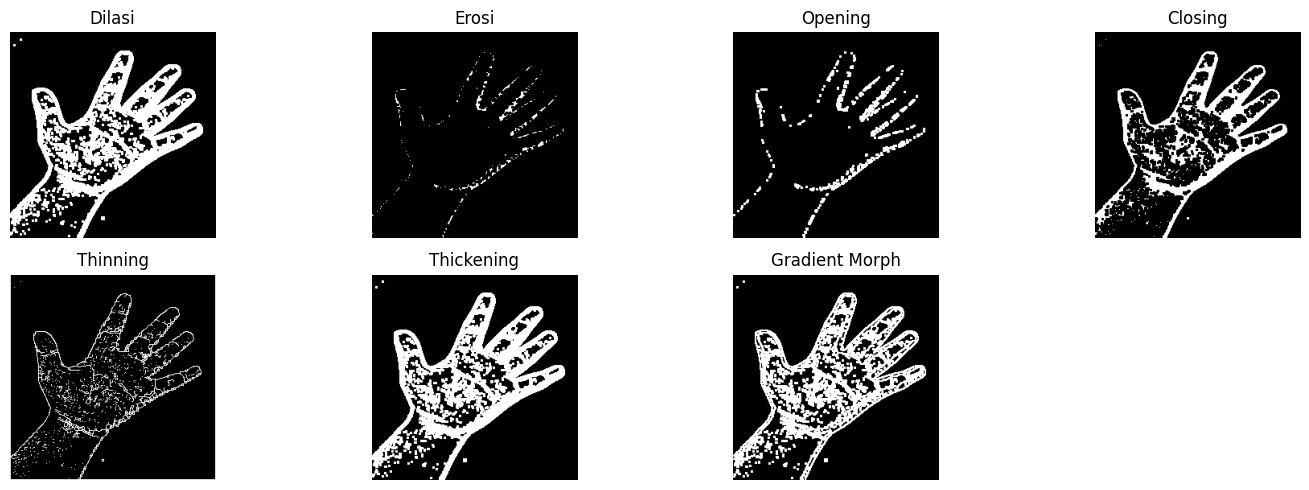

In [98]:
hasil_dilasi    = dilasi(Threshold20, kernel3x3)
hasil_erosi     = erosi(Threshold20, kernel3x3)
hasil_opening   = opening(Threshold20, kernel3x3)
hasil_closing   = closing(Threshold20, kernel3x3)
hasil_thinning  = thinning(Threshold20)
hasil_thickening = thickening(Threshold20, kernel3x3)
hasil_gradient  = hasil_dilasi - hasil_erosi


plt.figure(figsize=(15,5))

plt.subplot(2,4,1)
plt.imshow(hasil_dilasi, cmap='gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2,4,2)
plt.imshow(hasil_erosi, cmap='gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2,4,3)
plt.imshow(hasil_opening, cmap='gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2,4,4)
plt.imshow(hasil_closing, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2,4,5)
plt.imshow(hasil_thinning, cmap='gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2,4,6)
plt.imshow(hasil_thickening, cmap='gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2,4,7)
plt.imshow(hasil_gradient, cmap='gray')
plt.title('Gradient Morph')
plt.axis('off')

plt.tight_layout()
plt.show()

## Analisis Hasil Operasi Morfologi Kernel 3×3

Berdasarkan hasil operasi morfologi menggunakan kernel 3×3, terlihat beberapa perubahan pada bentuk objek tangan dibandingkan citra asli sebelum proses morfologi dilakukan.

1. **Dilasi**  
   Objek tangan menjadi lebih tebal dan area putih bertambah. Operasi ini membantu memperjelas bentuk tangan dan menyambungkan bagian tepi yang terputus kecil.

2. **Erosi**  
   Area putih pada objek berkurang sehingga tangan terlihat lebih tipis. Noise kecil ikut berkurang, tetapi beberapa detail kecil pada jari juga ikut hilang.

3. **Opening**  
   Opening berhasil mengurangi noise kecil di sekitar objek tangan. Bentuk utama tangan masih tetap terlihat sehingga hasil menjadi lebih bersih dibanding citra asli.

4. **Closing**  
   Closing membantu menutup lubang kecil pada objek tangan dan membuat bentuk tangan terlihat lebih utuh dan lebih penuh dibanding hasil opening.

5. **Thinning**  
   Garis objek menjadi lebih tipis sehingga struktur dasar dan kontur tangan terlihat lebih jelas dibanding citra asli.

6. **Thickening**  
   Objek tangan tampak lebih tebal dan garis tepi menjadi lebih kuat sehingga bentuk tangan lebih mudah diamati.

7. **Gradient Morph**  
   Operasi ini menampilkan bagian tepi objek hasil selisih antara dilasi dan erosi. Kontur tangan terlihat jelas sehingga cocok digunakan untuk melihat batas objek.

### Perbandingan dengan Citra Asli
- Setelah proses morfologi, noise pada citra berkurang dibanding citra asli.
- Bentuk objek tangan menjadi lebih jelas dan mudah dikenali.
- Kernel 3×3 masih mampu mempertahankan detail objek lebih baik karena perubahan pada citra tidak terlalu agresif.
- Operasi dilasi dan thickening mempertebal objek, sedangkan erosi dan thinning menipiskan objek.
- Opening dan closing membantu memperbaiki kualitas objek dengan mengurangi noise dan memperjelas bentuk tangan.

# Operasi Morfologi Menggunakan Kernel 5x5

Kode digunakan untuk menerapkan operasi morfologi menggunakan kernel 5x5 pada citra hasil threshold.  
Operasi yang dilakukan meliputi dilasi, erosi, opening, closing, thinning, thickening, dan gradient morph, kemudian seluruh hasil ditampilkan dalam bentuk subplot untuk dibandingkan.

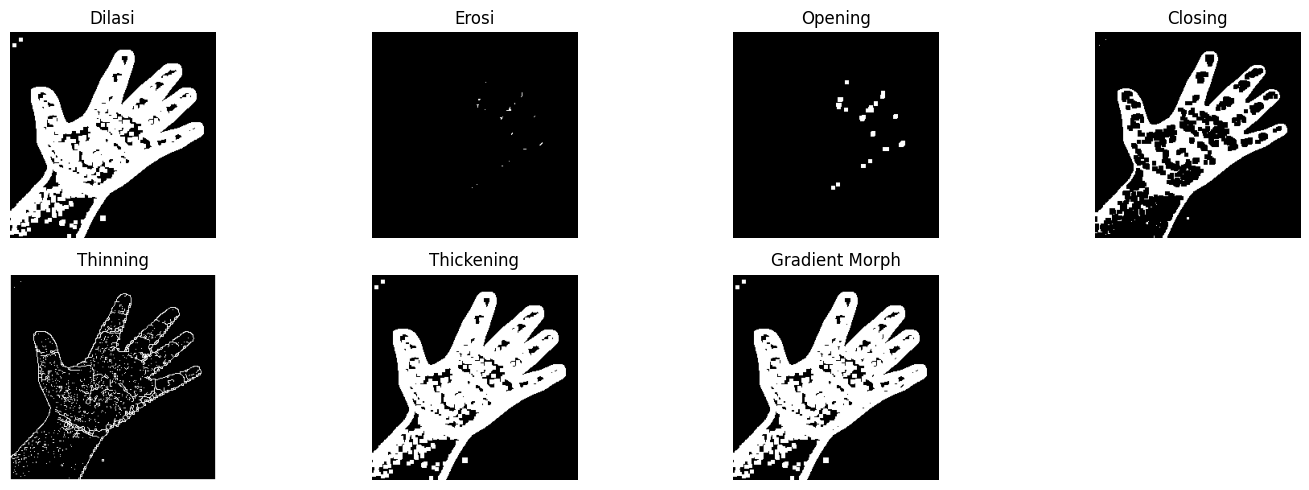

In [99]:
hasil_dilasi2    = dilasi(Threshold20, kernel5x5)
hasil_erosi2     = erosi(Threshold20, kernel5x5)
hasil_opening2   = opening(Threshold20, kernel5x5)
hasil_closing2   = closing(Threshold20, kernel5x5)
hasil_thinning2  = thinning(Threshold20)
hasil_thickening2 = thickening(Threshold20, kernel5x5)
hasil_gradient2  = hasil_dilasi2 - hasil_erosi2


plt.figure(figsize=(15,5))

plt.subplot(2,4,1)
plt.imshow(hasil_dilasi2, cmap='gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2,4,2)
plt.imshow(hasil_erosi2, cmap='gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2,4,3)
plt.imshow(hasil_opening2, cmap='gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2,4,4)
plt.imshow(hasil_closing2, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2,4,5)
plt.imshow(hasil_thinning2, cmap='gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2,4,6)
plt.imshow(hasil_thickening2, cmap='gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2,4,7)
plt.imshow(hasil_gradient2, cmap='gray')
plt.title('Gradient Morph')
plt.axis('off')

plt.tight_layout()
plt.show()

## Analisis Hasil Operasi Morfologi Menggunakan Kernel 5×5

Berdasarkan hasil operasi morfologi menggunakan kernel 5×5, terlihat perubahan yang lebih besar dibandingkan kernel 3×3 karena ukuran kernel yang lebih besar mempengaruhi area piksel yang diproses.

1. **Dilasi**  
   Objek tangan menjadi jauh lebih tebal dibanding kernel 3×3. Area putih semakin melebar sehingga bentuk tangan terlihat lebih dominan, namun beberapa detail kecil mulai hilang.

2. **Erosi**  
   Banyak bagian objek menghilang karena kernel 5×5 mengikis objek lebih kuat dibanding kernel 3×3. Hanya bagian terang tertentu yang masih tersisa.

3. **Opening**  
   Noise berhasil dikurangi lebih banyak dibanding kernel 3×3, tetapi detail tangan juga ikut hilang sehingga beberapa bagian objek terlihat terputus-putus.

4. **Closing**  
   Lubang kecil pada objek tertutup lebih baik dan bentuk tangan terlihat lebih penuh. Dibanding kernel 3×3, hasil closing 5×5 membuat objek tampak lebih tebal.

5. **Thinning**  
   Garis objek menjadi lebih tipis dan struktur dasar tangan terlihat jelas. Namun detail kecil berkurang akibat pengaruh kernel yang lebih besar.

6. **Thickening**  
   Objek tangan menjadi lebih tebal dibanding hasil kernel 3×3. Area putih bertambah luas sehingga kontur tangan terlihat lebih kuat.

7. **Gradient Morph**  
   Kontur tangan terlihat jelas karena merupakan hasil selisih antara dilasi dan erosi. Dengan kernel 5×5, garis batas objek terlihat lebih tegas dibanding kernel 3×3.

### Perbandingan Kernel 5×5 dan 3×3
- Kernel **5×5** menghasilkan perubahan yang lebih kuat pada bentuk objek.
- Ketebalan objek pada hasil dilasi dan thickening menjadi lebih besar dibanding kernel 3×3.
- Noise lebih banyak berkurang pada kernel 5×5, tetapi detail kecil citra juga lebih banyak hilang.
- Kernel **3×3** lebih baik dalam mempertahankan detail objek, sedangkan kernel **5×5** lebih efektif untuk mempertegas bentuk dan mengurangi noise.
- Semakin besar kernel yang digunakan, maka efek morfologi terhadap citra akan semakin kuat.

# Kombinasi Operasi Morfologi

Kode digunakan untuk menggabungkan beberapa operasi morfologi pada citra threshold menggunakan kernel 3x3.  
Kombinasi yang digunakan yaitu Opening + Closing, Closing + Opening, Opening + Dilasi, dan Closing + Erosi untuk melihat perubahan bentuk objek setelah beberapa proses morfologi dilakukan secara berurutan.

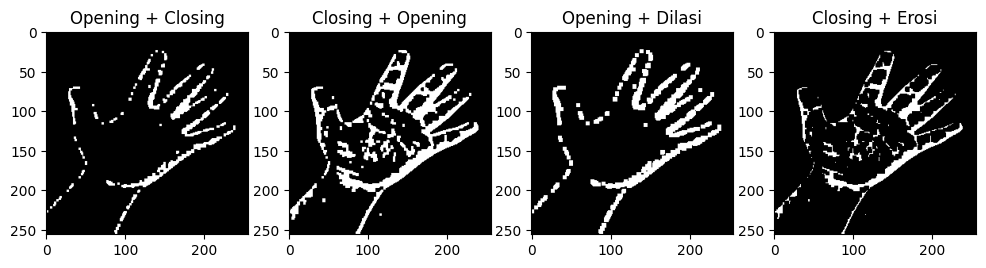

In [100]:
OpeningClosing = closing(opening(Threshold20, kernel3x3), kernel3x3)
ClosingOpening = opening(closing(Threshold20, kernel3x3), kernel3x3)
OpeningDilasi = dilasi(opening(Threshold20, kernel3x3), kernel3x3)
ClosingErosi = erosi(closing(Threshold20, kernel3x3), kernel3x3)

plt.figure(figsize=(12,8))

plt.subplot(1,4,1)
plt.imshow(OpeningClosing, cmap='gray')
plt.title('Opening + Closing')

plt.subplot(1,4,2)
plt.imshow(ClosingOpening, cmap='gray')
plt.title('Closing + Opening')

plt.subplot(1,4,3)
plt.imshow(OpeningDilasi, cmap='gray')
plt.title('Opening + Dilasi')

plt.subplot(1,4,4)
plt.imshow(ClosingErosi, cmap='gray')
plt.title('Closing + Erosi')

plt.show()

## Analisis Hasil Kombinasi Operasi Morfologi

Berdasarkan hasil kombinasi operasi morfologi pada citra telapak tangan, setiap kombinasi memberikan perubahan yang berbeda terhadap bentuk objek, noise, dan kejelasan tepi dibandingkan citra asli maupun operasi tunggal.

1. **Opening + Closing**  
   Kombinasi ini menghasilkan objek tangan yang lebih bersih dan rapi. Noise kecil berhasil dikurangi melalui proses opening, kemudian closing membantu memperhalus bentuk objek dan menutup celah kecil pada tepi tangan. Garis kontur terlihat cukup jelas dan stabil.

2. **Closing + Opening**  
   Hasil kombinasi ini membuat objek tangan terlihat lebih tebal dan lebih penuh dibanding opening + closing. Closing terlebih dahulu menutup lubang kecil pada objek, lalu opening membersihkan noise. Namun masih terlihat beberapa area putih di dalam objek tangan.

3. **Opening + Dilasi**  
   Setelah noise dikurangi dengan opening, proses dilasi membuat garis tangan menjadi lebih tebal dan lebih jelas. Kontur jari terlihat lebih kuat dibanding hasil operasi tunggal, tetapi ukuran objek sedikit membesar.

4. **Closing + Erosi**  
   Closing memperbaiki bentuk objek dan menyambungkan bagian yang terputus, sedangkan erosi menipiskan kembali bagian tepi. Hasil akhir terlihat lebih halus dan tidak terlalu tebal, namun beberapa detail kecil mulai berkurang.

### Perbandingan dengan Operasi Tunggal dan Citra Asli
- Dibanding citra asli, kombinasi operasi morfologi membuat kontur tangan lebih jelas dan noise lebih sedikit.
- Dibanding operasi tunggal, kombinasi operasi menghasilkan bentuk objek yang lebih stabil karena proses saling melengkapi antara penghilangan noise dan perbaikan bentuk objek.
- Opening lebih efektif untuk membersihkan noise, sedangkan closing lebih baik dalam memperbaiki bentuk objek dan menutup lubang kecil.
- Dilasi mempertebal objek, sementara erosi menipiskan objek dan mengurangi detail kecil.

### Kesimpulan
Kombinasi operasi morfologi memberikan hasil yang lebih baik dibanding operasi tunggal karena mampu menyeimbangkan pengurangan noise, ketebalan objek, dan kejelasan batas objek. Pada hasil ini, kombinasi **Opening + Closing** dan **Opening + Dilasi** memberikan kontur tangan yang paling jelas dan rapi.

# Konversi Citra Telapak ke Grayscale

Kode digunakan untuk membaca citra `Telapak.jpeg`, kemudian mengubah citra berwarna menjadi citra grayscale menggunakan fungsi `cv2.cvtColor()`.  
Hasil grayscale ditampilkan untuk mempermudah proses pengolahan citra selanjutnya seperti thresholding dan deteksi tepi.

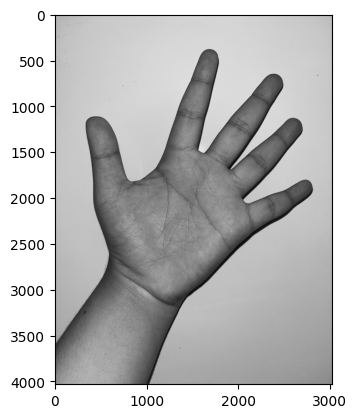

In [101]:
Tangan2 = cv2.imread('Telapak.jpeg')
hasiltelapak = cv2.cvtColor(Tangan2, cv2.COLOR_RGB2GRAY)
plt.imshow(hasiltelapak, cmap='gray')
plt.show()

# Resize Citra Telapak

Kode digunakan untuk mengubah ukuran citra grayscale telapak tangan menjadi 520 × 520 piksel menggunakan fungsi `resized()`.  
Proses resize dilakukan agar ukuran citra menjadi seragam dan lebih mudah diproses pada tahap pengolahan citra berikutnya.

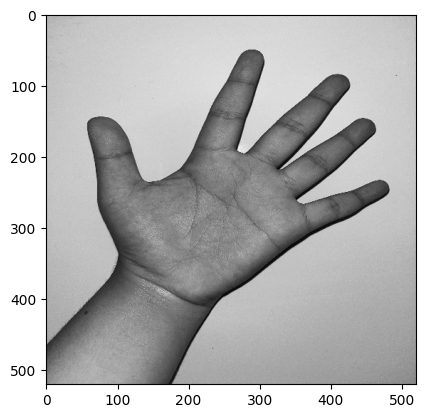

In [102]:
resizee = resized(hasiltelapak, 520, 520)
plt.imshow(resizee, cmap='gray')
plt.show()

# Fungsi Filter Mean, Median, dan Modus

Kode digunakan untuk membuat fungsi filter citra dengan tiga mode berbeda, yaitu **mean**, **median**, dan **modus**.  
Setiap filter bekerja menggunakan kernel berukuran tertentu untuk memperbaiki kualitas citra dan mengurangi noise.

- **Mean Filter** digunakan untuk menghaluskan citra dengan menghitung rata-rata nilai piksel di sekitar area kernel.
- **Median Filter** digunakan untuk mengurangi noise dengan mengambil nilai tengah dari piksel pada area kernel.
- **Modus Filter** digunakan untuk memilih nilai piksel yang paling sering muncul pada area kernel sehingga dapat mempertahankan pola dominan citra.

In [103]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2

    padded = np.pad(img, pad, mode='edge')

    canvas = np.zeros_like(img)

    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    total = 0
                    for r in range(size):
                        for c in range(size):
                            total += padded[i + r][j + c]
                    canvas[i][j] = np.around(total / area)

        case 'median':
            for i in range(height):
                for j in range(width):
                    n = size * size
                    values = [0] * n
                    idx = 0
                    for r in range(size):
                        for c in range(size):
                            values[idx] = padded[i + r][j + c]
                            idx += 1
                    for x in range(n):
                        for y in range(n - x - 1):
                            if values[y] > values[y + 1]:
                                values[y], values[y + 1] = values[y + 1], values[y]
                    canvas[i][j] = values[n // 2]

        case 'modus':
            for i in range(height):
                for j in range(width):
                    n = size * size
                    values = [0] * n
                    idx = 0
                    for r in range(size):
                        for c in range(size):
                            values[idx] = padded[i + r][j + c]
                            idx += 1
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val in count.keys():
                        freq = count[val]
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i][j] = mode_val

    return canvas

# Median Filter pada Citra Telapak

Kode digunakan untuk menerapkan **median filter** berukuran 3×3 pada citra hasil resize.  
Median filter bekerja dengan mengambil nilai tengah dari piksel di sekitar area kernel sehingga dapat mengurangi noise tanpa terlalu menghilangkan detail tepi pada citra.

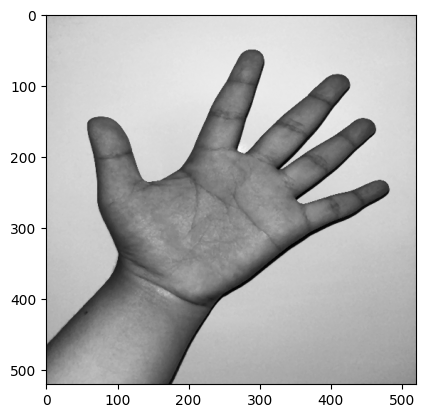

In [104]:
median = filter(resizee, 3, 'median')
plt.imshow(median, cmap= 'gray')
plt.show()

# Deteksi Tepi Menggunakan Operator Prewitt

Kode digunakan untuk melakukan deteksi tepi pada citra hasil median filter menggunakan operator Prewitt.  
Operator Prewitt membantu menampilkan batas dan kontur objek tangan sehingga bentuk tepi objek terlihat lebih jelas dibanding citra sebelumnya.

<function matplotlib.pyplot.show(close=None, block=None)>

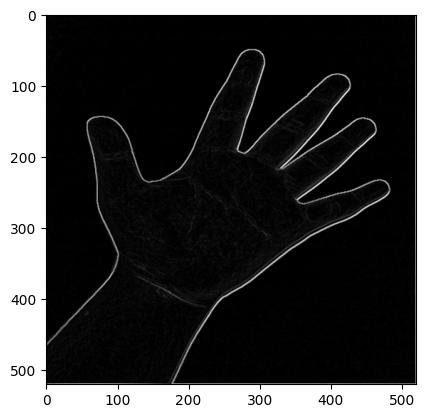

In [105]:
tepi = edge (median, prewittX, prewittY)
plt.imshow(tepi, cmap= 'gray')
plt.show

# Threshold pada Hasil Deteksi Tepi

Kode digunakan untuk menerapkan proses threshold dengan nilai batas 20 pada citra hasil deteksi tepi.  
Proses ini mengubah citra menjadi biner, dimana bagian tepi objek akan berwarna putih dan background menjadi hitam sehingga bentuk objek tangan terlihat lebih jelas.

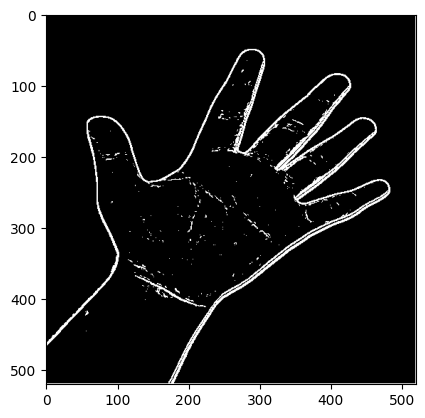

In [106]:
treshollagi = threshold(tepi, 20)
plt.imshow(treshollagi, cmap= 'gray')
plt.show()

# Thickening pada Citra Threshold

Kode digunakan untuk melakukan proses **thickening** pada citra hasil threshold menggunakan kernel berbentuk cross.  
Proses thickening bertujuan untuk menebalkan bagian objek dan garis tepi sehingga bentuk tangan terlihat lebih jelas dan lebih mudah diamati.

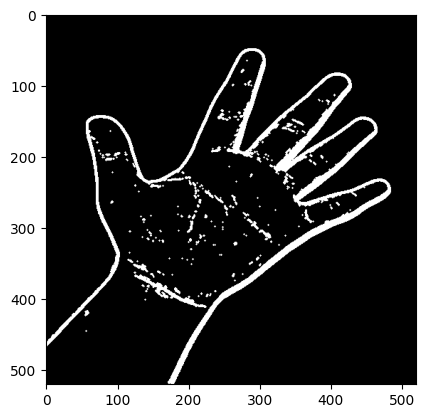

In [107]:
thickeningg = thickening(treshollagi, kernel_cross)
plt.imshow(thickeningg, cmap= 'gray')
plt.show()

# Deteksi Tepi Setelah Thickening

Kode digunakan untuk melakukan deteksi tepi kembali pada citra hasil thickening menggunakan operator Prewitt. 

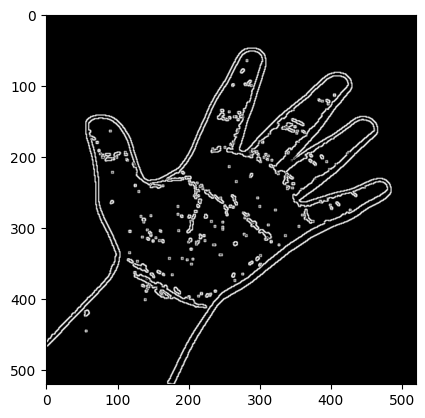

In [108]:
tepi = edge (thickeningg, prewittX, prewittY)
plt.imshow(tepi, cmap= 'gray')
plt.show()

## Analisis Hasil Eksplorasi Mandiri

Berdasarkan proses yang telah dilakukan, beberapa tahapan pengolahan citra digunakan untuk menghasilkan garis kontur telapak tangan yang lebih jelas.

1. **Grayscale**  
   Citra awal diubah menjadi grayscale agar proses pengolahan lebih mudah karena hanya menggunakan intensitas abu-abu.

2. **Resize**  
   Ukuran citra diseragamkan menjadi 520×520 piksel sehingga proses filtering dan deteksi tepi menjadi lebih stabil.

3. **Filtering (Median Filter)**  
   Median filter digunakan untuk mengurangi noise pada citra tanpa terlalu menghilangkan detail tepi tangan. Hasilnya citra menjadi lebih halus.

4. **Deteksi Tepi (Prewitt)**  
   Operator Prewitt digunakan untuk menampilkan garis tepi telapak tangan. Kontur jari dan bentuk tangan mulai terlihat jelas.

5. **Thresholding**  
   Proses threshold mengubah citra menjadi biner sehingga tepi objek terlihat lebih tegas antara warna hitam dan putih.

6. **Operasi Morfologi (Thickening)**  
   Thickening digunakan untuk menebalkan garis tepi hasil threshold sehingga outline tangan menjadi lebih kuat dan mudah diamati.

7. **Deteksi Tepi Setelah Thickening**  
   Setelah dilakukan thickening, garis kontur tangan terlihat lebih jelas dan menyatu. Detail bentuk jari menjadi lebih mudah dikenali walaupun masih terdapat sedikit noise kecil pada bagian dalam objek.

### Kesimpulan
Kombinasi resize, filtering, deteksi tepi, thresholding, dan operasi morfologi berhasil menghasilkan outline telapak tangan yang lebih jelas. Proses yang paling berpengaruh terhadap hasil akhir adalah median filter, thresholding, dan thickening karena membantu mengurangi noise serta mempertegas kontur objek tangan.